In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_squared_error

from xgboost import XGBRegressor
# Install catboost if not already installed
!pip install catboost
from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [5]:
df = pd.read_csv("/content/Air_quality_data.csv")

print(df.shape)
df.head()

(18265, 13)


,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,325.8,Very Poor
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,262.7,Poor
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,341.8,Very Poor
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,206.3,Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,339.8,Very Poor


In [6]:
# Missing values fill
df = df.fillna(df.median(numeric_only=True))

# Drop useless columns (if exist)
df = df.drop(columns=['Date', 'City'], errors='ignore')

In [21]:
df['PM_ratio'] = df['PM2.5'] / (df['PM10'] + 1)

df['pollution_sum'] = df[['PM2.5','PM10','NO2','SO2','CO']].sum(axis=1)
df['pollution_mean'] = df[['PM2.5','PM10','NO2','SO2','CO']].mean(axis=1)
df['pollution_std'] = df[['PM2.5','PM10','NO2','SO2','CO']].std(axis=1)

# 🔥 NEW FEATURES (IMPORTANT)
df['PM_interaction'] = df['PM2.5'] * df['PM10']
df['gas_interaction'] = df['NO2'] * df['SO2']
df['pollution_index'] = df['pollution_sum'] / (df['pollution_mean'] + 1)

df['PM2.5_sq'] = df['PM2.5'] ** 2
df['PM10_sq'] = df['PM10'] ** 2

In [22]:
df = df[df['AQI'] < df['AQI'].quantile(0.98)]

In [26]:
X = df.drop(columns=['AQI'])
y = np.log1p(df['AQI'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.feature_selection import SelectKBest, f_regression

selector = SelectKBest(score_func=f_regression, k=8)

X_train = selector.fit_transform(X_train_numeric, y_train)
X_test = selector.transform(X_test_numeric)

In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
linear = Pipeline([
    ('poly', PolynomialFeatures(degree=3)),
    ('ridge', Ridge(alpha=20))
])
linear.fit(X_train_scaled_fs, y_train)

y_lr = linear.predict(X_test_scaled_fs)

In [45]:
svm = SVR(
    kernel='rbf',
    C=500,
    gamma='scale',
    epsilon=0.2
)
svm.fit(X_train_scaled_fs, y_train)

y_svm = svm.predict(X_test_scaled_fs)

In [36]:
xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb.fit(X_train, y_train)

y_xgb = xgb.predict(X_test)

In [37]:
cat = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=0
)

cat.fit(X_train, y_train)

y_cat = cat.predict(X_test)

In [38]:
def evaluate(y_true, y_pred):
    y_true = np.expm1(y_true)
    y_pred = np.expm1(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return rmse, r2

In [46]:
models = {
    "Linear Regression": y_lr,
    "SVM": y_svm,
    "XGBoost": y_xgb,
    "CatBoost": y_cat
}

results = []

for name, pred in models.items():
    rmse, r2 = evaluate(y_test, pred)
    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2 Score"])

results_df.sort_values(by="R2 Score", ascending=False)

,Model,RMSE,R2 Score
2,XGBoost,16.557357,0.977505
3,CatBoost,17.601324,0.974579
1,SVM,53.236651,0.767446
0,Linear Regression,61.979329,0.684793


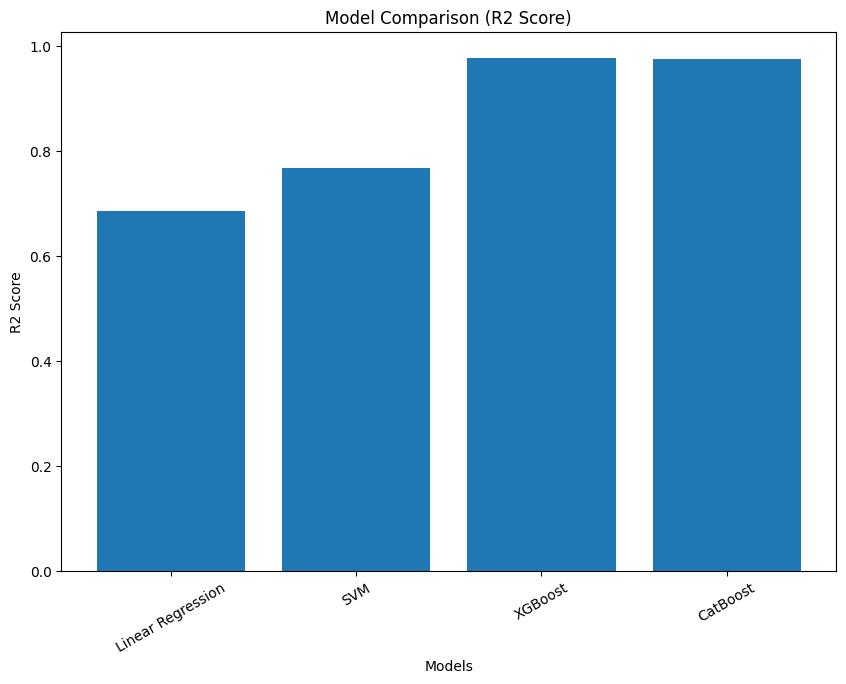

In [47]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results_df['Model'], results_df['R2 Score'])
plt.title("Model Comparison (R2 Score)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)
plt.show()

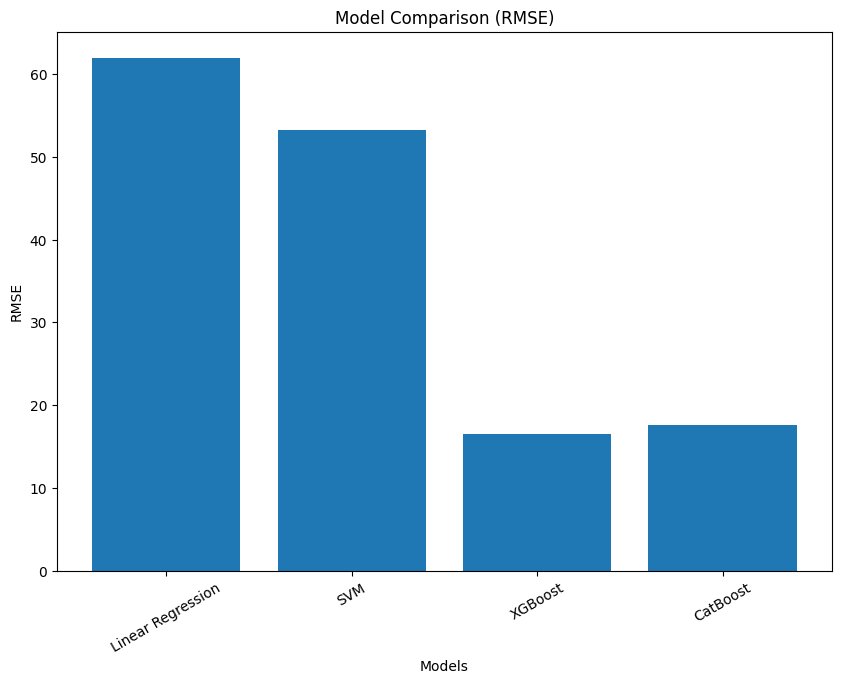

In [48]:
plt.figure()
plt.bar(results_df['Model'], results_df['RMSE'])
plt.title("Model Comparison (RMSE)")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()

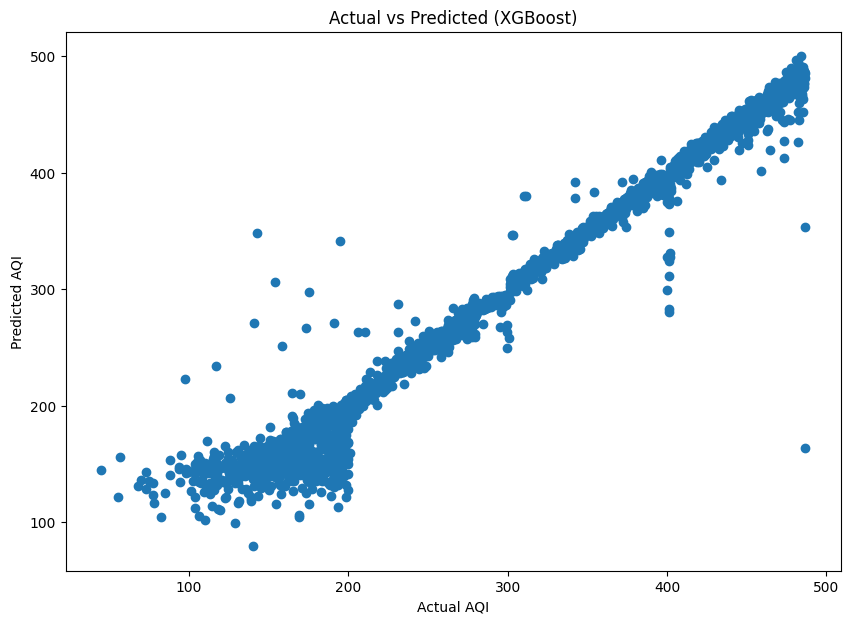

In [49]:
y_true = np.expm1(y_test)
y_pred = np.expm1(y_xgb)

plt.figure()
plt.scatter(y_true, y_pred)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted (XGBoost)")
plt.show()

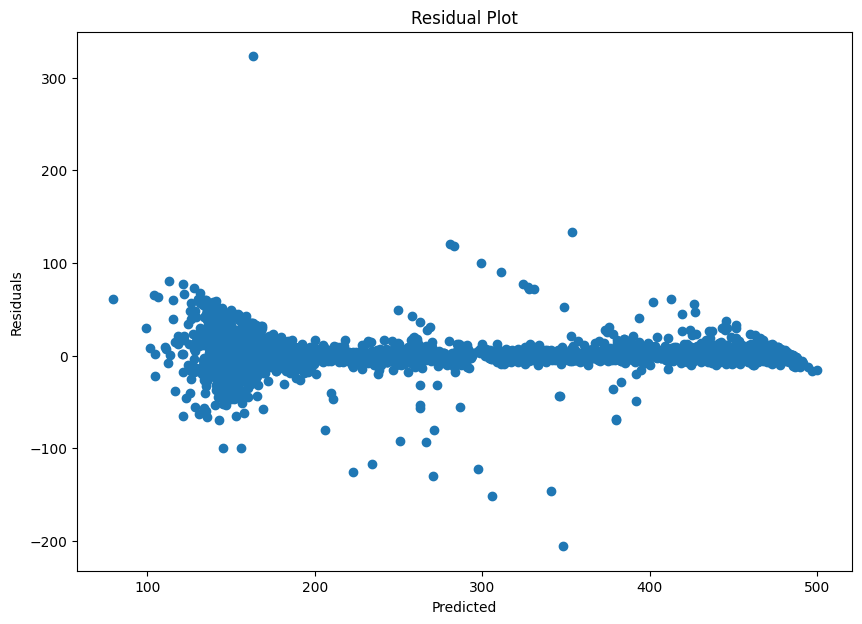

In [50]:
residuals = y_true - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

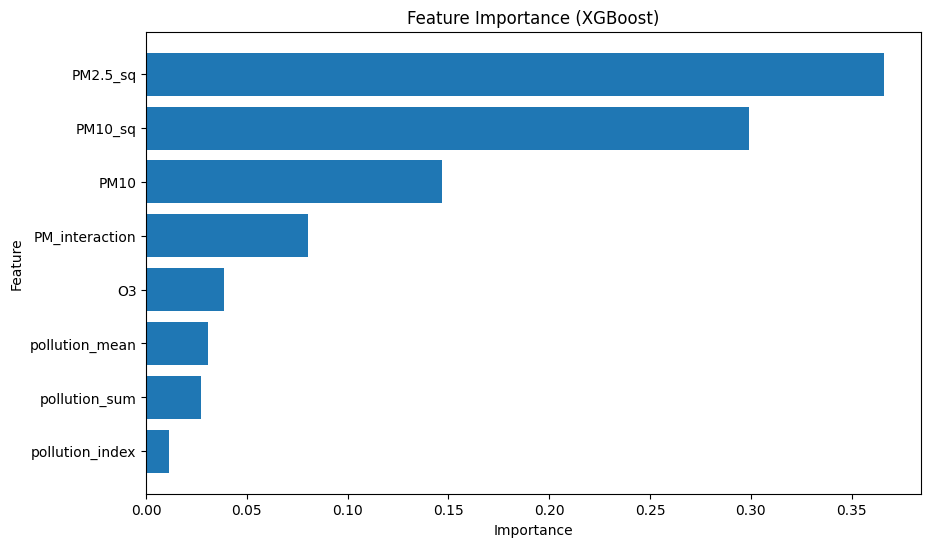

In [52]:
import pandas as pd
import matplotlib.pyplot as plt

importance = xgb.feature_importances_
features = selector.get_feature_names_out(X_train_numeric.columns)

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

In [53]:
import shap

explainer = shap.Explainer(xgb, X_train)
shap_values = explainer(X_test)

 99%|===================| 3477/3507 [01:42<00:00]       

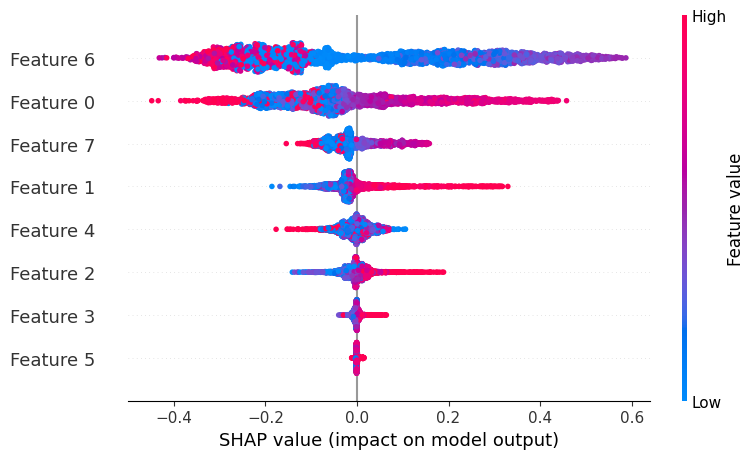

In [54]:
shap.summary_plot(shap_values, X_test)

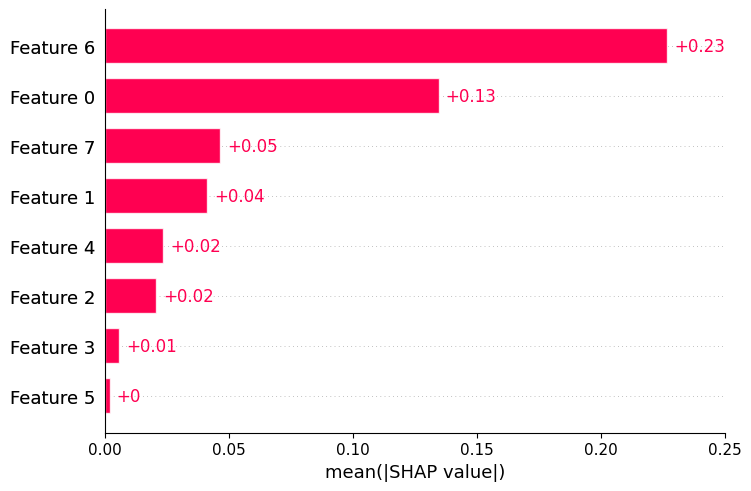

In [55]:
shap.plots.bar(shap_values)

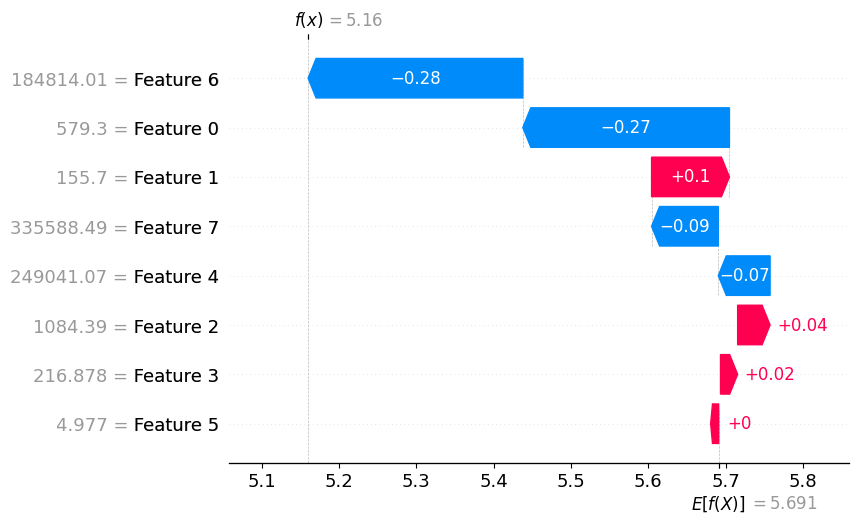

In [56]:
shap.plots.waterfall(shap_values[0])

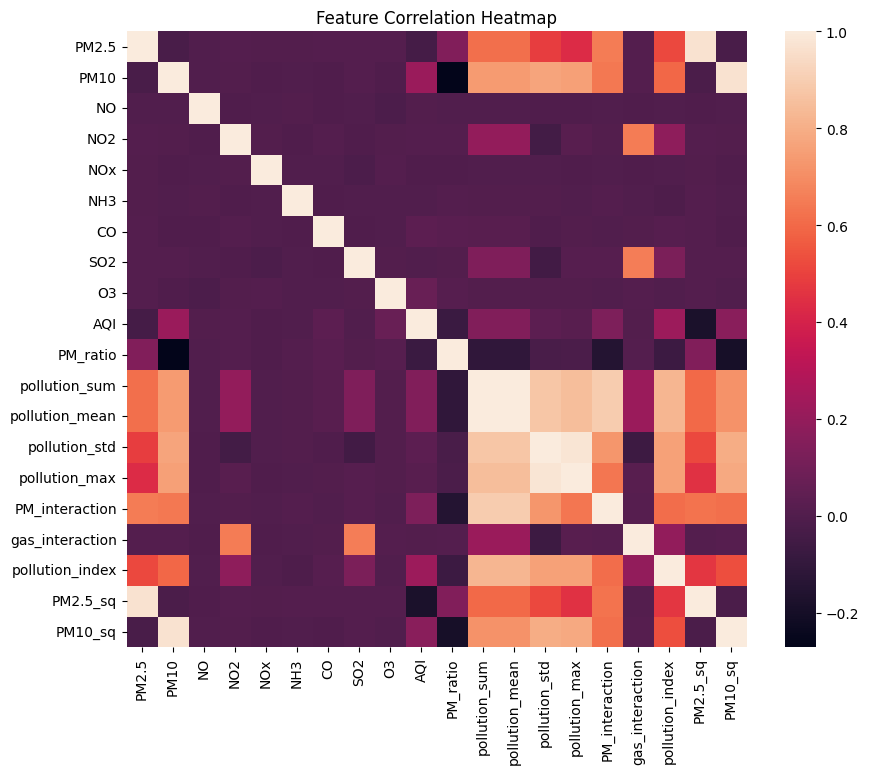

In [58]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=['Datetime', 'AQI_Bucket'], errors='ignore').corr(), annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

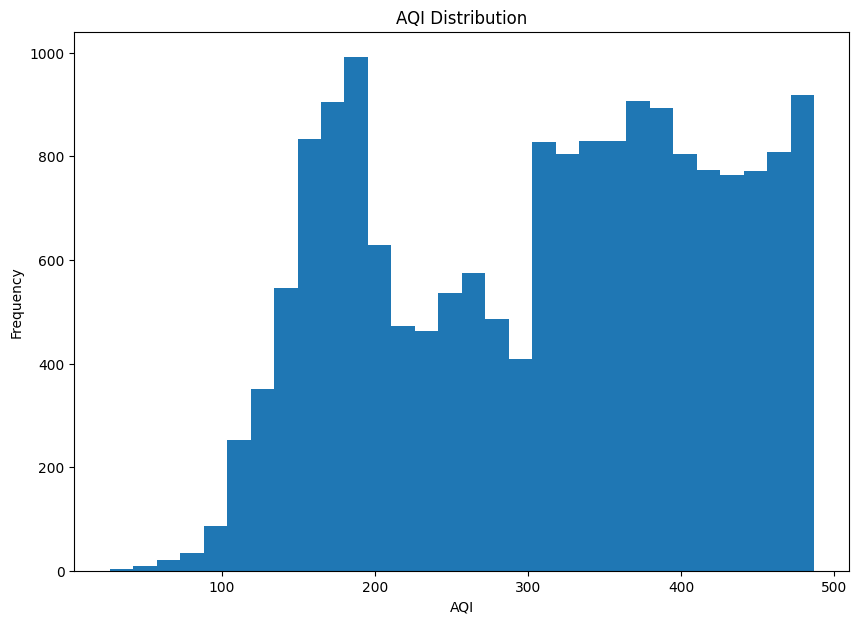

In [59]:
plt.figure()
plt.hist(df['AQI'], bins=30)
plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

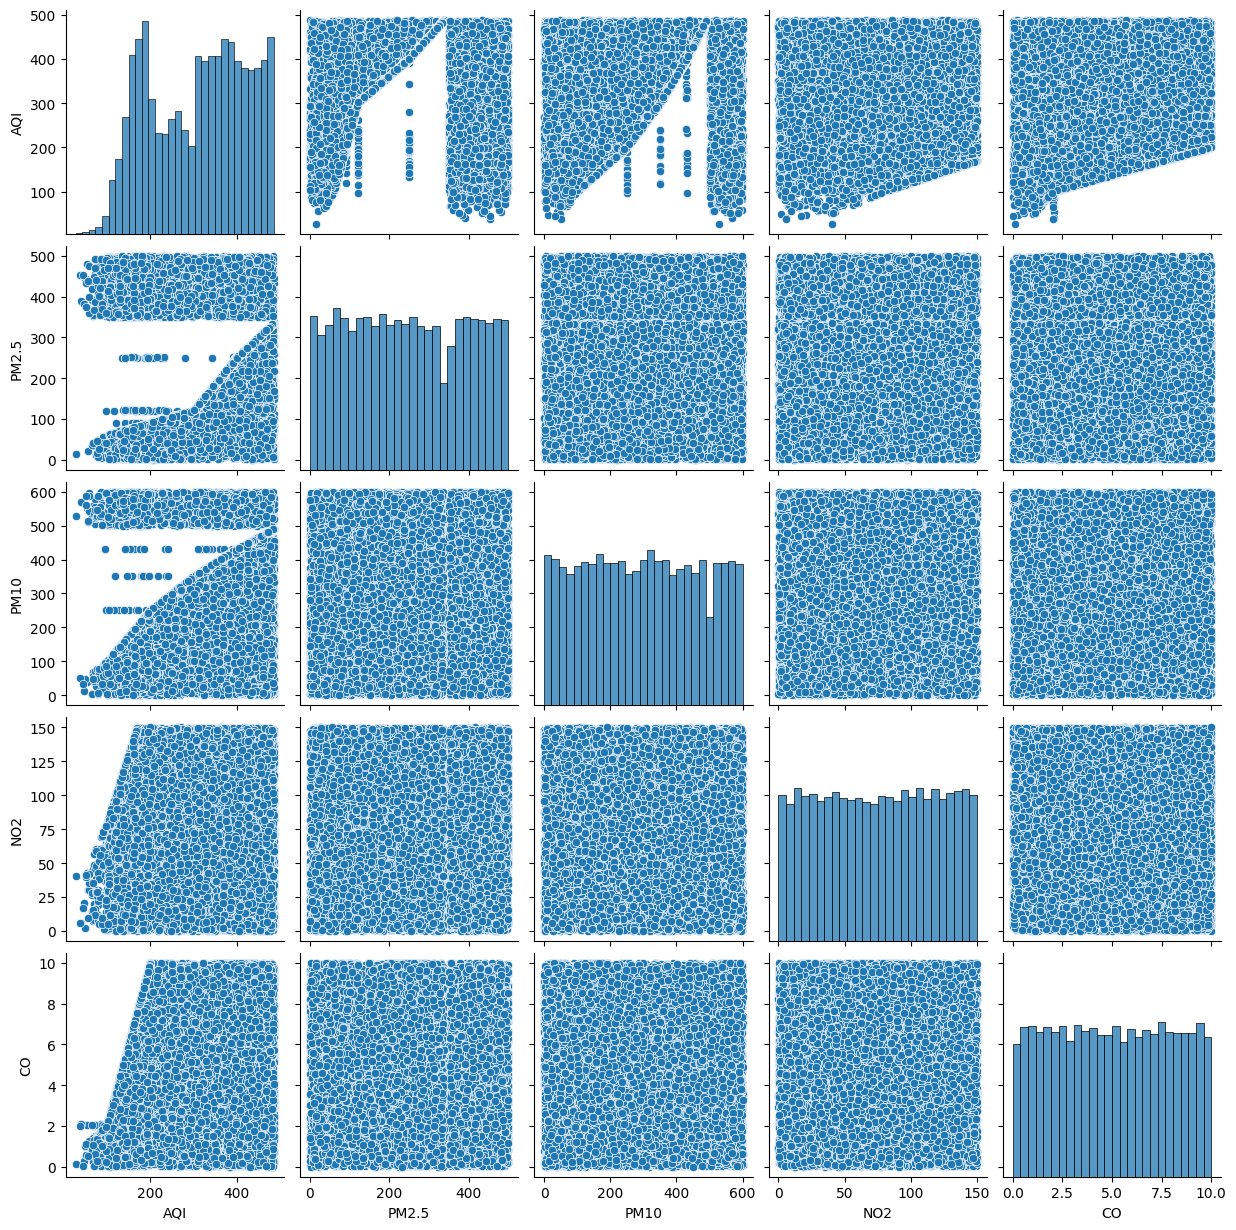

In [65]:
import seaborn as sns

sns.pairplot(df[['AQI','PM2.5','PM10','NO2','CO']])
plt.show()

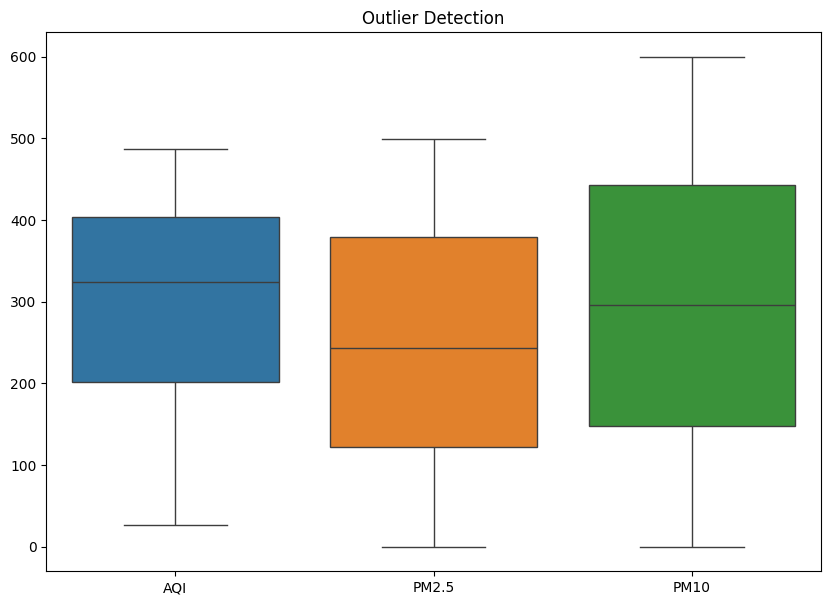

In [66]:
plt.figure()
sns.boxplot(data=df[['AQI','PM2.5','PM10']])
plt.title("Outlier Detection")
plt.show()

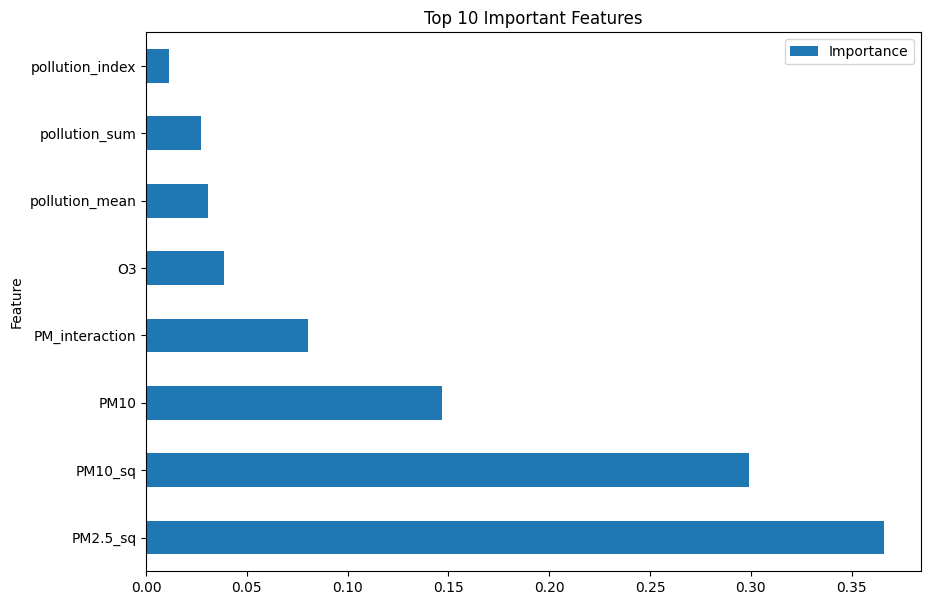

In [67]:
feat_imp.head(10).plot(kind='barh', x='Feature', y='Importance')
plt.title("Top 10 Important Features")
plt.show()

In [68]:
results_df.style.background_gradient(cmap='coolwarm')

,Model,RMSE,R2 Score
0,Linear Regression,61.979329,0.684793
1,SVM,53.236651,0.767446
2,XGBoost,16.557357,0.977505
3,CatBoost,17.601324,0.974579


In [70]:
import time

def evaluate_full(model, X_train, X_test, y_train, y_test, name):

    results = []

    # TRAINING
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    def calc_metrics(y_true, y_pred):
        y_true = np.expm1(y_true)
        y_pred = np.expm1(y_pred)

        r2 = r2_score(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = np.mean(np.abs(y_true - y_pred))
        mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

        return r2, rmse, mape, mae

    # Training metrics
    r2, rmse, mape, mae = calc_metrics(y_train, y_train_pred)
    results.append([name, "Training", r2, rmse, mape, mae, train_time])

    # Testing metrics
    r2, rmse, mape, mae = calc_metrics(y_test, y_test_pred)
    results.append([name, "Testing", r2, rmse, mape, mae, train_time])

    # All data
    X_all = np.vstack((X_train, X_test))
    y_all = np.concatenate((y_train, y_test))

    y_all_pred = model.predict(X_all)
    r2, rmse, mape, mae = calc_metrics(y_all, y_all_pred)
    results.append([name, "All dataset", r2, rmse, mape, mae, train_time])

    return results

In [71]:
from sklearn.ensemble import RandomForestRegressor

all_results = []

# Linear
all_results += evaluate_full(linear, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression")

# SVM
all_results += evaluate_full(svm, X_train_scaled, X_test_scaled, y_train, y_test, "SVM")

# XGBoost
all_results += evaluate_full(xgb, X_train, X_test, y_train, y_test, "XGBoost")

# CatBoost
all_results += evaluate_full(cat, X_train, X_test, y_train, y_test, "CatBoost")

# Random Forest (NEW 🔥)
rf = RandomForestRegressor(n_estimators=200)
all_results += evaluate_full(rf, X_train, X_test, y_train, y_test, "Random Forest")

In [74]:
columns = ["Model", "Dataset", "R2", "RMSE", "MAPE (%)", "MAE", "Time (s)"]

final_df = pd.DataFrame(all_results, columns=columns)

final_df

,Model,Dataset,R2,RMSE,MAPE (%),MAE,Time (s)
0,Linear Regression,Training,0.717773,58.581594,15.353751,41.679236,0.179805
1,Linear Regression,Testing,0.727941,57.581198,15.265965,41.522072,0.179805
2,Linear Regression,All dataset,0.719814,58.382887,15.336193,41.647803,0.179805
3,SVM,Training,0.778452,51.903319,13.973595,39.888892,52.324372
4,SVM,Testing,0.778528,51.952798,13.941177,40.198375,52.324372
5,SVM,All dataset,0.778471,51.913219,13.967111,39.950789,52.324372
6,XGBoost,Training,0.992069,9.820406,2.404489,4.996149,1.235078
7,XGBoost,Testing,0.977505,16.557357,4.031484,7.656758,1.235078
8,XGBoost,All dataset,0.989151,11.488321,2.729888,5.528271,1.235078
9,CatBoost,Training,0.976825,16.786800,4.323279,9.100977,2.745643


In [75]:
final_df.style.background_gradient(cmap='coolwarm')

,Model,Dataset,R2,RMSE,MAPE (%),MAE,Time (s)
0,Linear Regression,Training,0.717773,58.581594,15.353751,41.679236,0.179805
1,Linear Regression,Testing,0.727941,57.581198,15.265965,41.522072,0.179805
2,Linear Regression,All dataset,0.719814,58.382887,15.336193,41.647803,0.179805
3,SVM,Training,0.778452,51.903319,13.973595,39.888892,52.324372
4,SVM,Testing,0.778528,51.952798,13.941177,40.198375,52.324372
5,SVM,All dataset,0.778471,51.913219,13.967111,39.950789,52.324372
6,XGBoost,Training,0.992069,9.820406,2.404489,4.996149,1.235078
7,XGBoost,Testing,0.977505,16.557357,4.031484,7.656758,1.235078
8,XGBoost,All dataset,0.989151,11.488321,2.729888,5.528271,1.235078
9,CatBoost,Training,0.976825,16.786800,4.323279,9.100977,2.745643


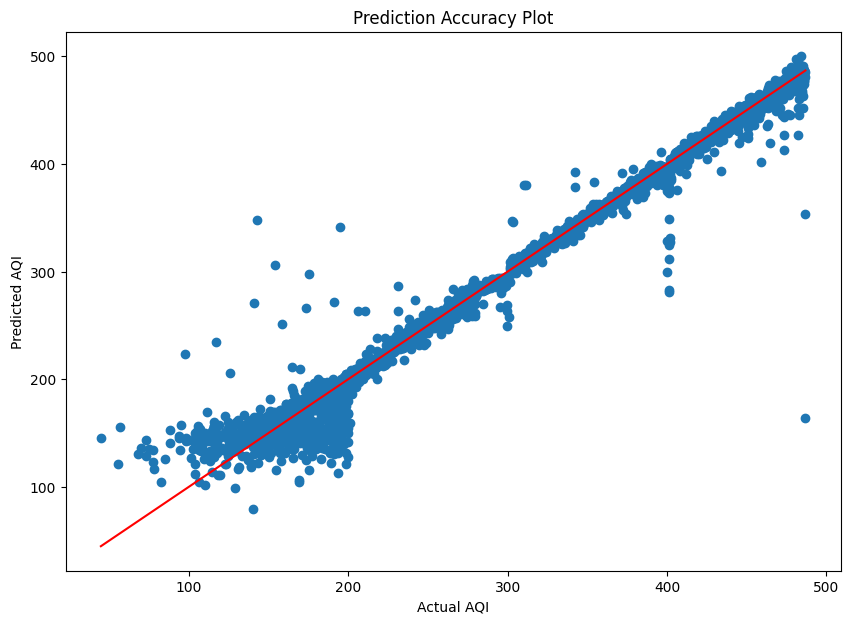

In [76]:
plt.figure()
plt.scatter(y_true, y_pred)

# Perfect prediction line
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         color='red')

plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Prediction Accuracy Plot")
plt.show()